# 05 — Modelagem

**Objetivo:** Treinar e comparar modelos de classificação para predição de turnover voluntário,
selecionar o melhor, otimizar o threshold de decisão e gerar o score de risco por colaborador.

**Referência SPEC:** Seções 11–14

---

| Entrada | Descrição |
|---|---|
| `data/processed/splits/train.parquet` | Split de treino (70% dos IDs) |
| `data/processed/splits/val.parquet` | Split de validação |
| `data/processed/splits/test.parquet` | Split de teste |
| `data/processed/splits/scaler_cols.json` | Metadados dos splits |
| `data/processed/feature_selection/selected_features.json` | Features selecionadas no notebook 04 |

| Saída | Descrição |
|---|---|
| `models/best_model.joblib` | Modelo treinado (melhor) |
| `models/model_metadata.json` | Threshold, M, features, AUC, parâmetros |
| `reports/figures/roc_pr_curves.png` | Curvas ROC e PR |

---

### Pipeline de modelagem

1. **Baseline** — Logistic Regression (class_weight="balanced")
2. **Modelos** — Random Forest, XGBoost, LightGBM
3. **Seleção** — ROC-AUC no val; comparação de F1/Recall
4. **Threshold** — Curva PR no val, filtros da SPEC §13
5. **Score de risco** — Função `calcular_score_risco(prob, T, M)` (SPEC §14)

## 1 · Setup & Configuração

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from pathlib import Path
from datetime import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")
print(f"Execução: {datetime.now():%Y-%m-%d %H:%M}")

pandas 2.3.3  ·  numpy 2.3.5
Execução: 2026-04-27 18:11


In [2]:
# ════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path.cwd().parent
DATA_SPLITS  = PROJECT_ROOT / "data" / "processed" / "splits"           # base; subpastas por grupo
FS_DIR       = PROJECT_ROOT / "data" / "processed" / "feature_selection" # base; subpastas por grupo
MODELS_DIR   = PROJECT_ROOT / "models"                                   # base; subpastas por grupo
REPORTS_DIR  = PROJECT_ROOT / "reports" / "figures"                      # base; subpastas por grupo

# ── Grupos operacionais ───────────────────────────────────────
# Cada grupo é modelado de forma independente, com seu próprio
# conjunto de features selecionadas, threshold e M (médio risco).
GRUPOS = ["Vendas", "Transporte", "Fábrica"]

# ── Constantes ────────────────────────────────────────────────
RNG_SEED              = 42
MEDIO_RISCO_PERCENTIL = 25   # percentil das probs treino para calcular M (SPEC §14)

print(f"Grupos   : {GRUPOS}")
print(f"Execução : {datetime.now():%Y-%m-%d %H:%M}")


Grupos   : ['Vendas', 'Transporte', 'Fábrica']
Execução : 2026-04-27 18:11


## 2 · Carga dos Splits


GRUPO: Vendas
  Features: 60  |  RFECV AUC: 0.8383
  Treino : 8,942 × 60  |  turnover: 38.78%
  Teste  : 3,780 × 60  |  turnover: 38.89%
  Val    : 5,335 × 60  |  turnover: 15.56%  (out-of-time)

  Modelo                  AUC-test  F1-test  Rec-test  Pre-test
  ------------------------------------------------------------


  LogisticRegression        0.7403   0.6158    0.6565    0.5799


  RandomForest              0.7933   0.6673    0.6803    0.6549


  XGBoost                   0.8168   0.6776    0.6857    0.6698


  LightGBM                  0.8197   0.6772    0.6844    0.6702

  ✓ Melhor: LightGBM  (AUC teste = 0.8197)


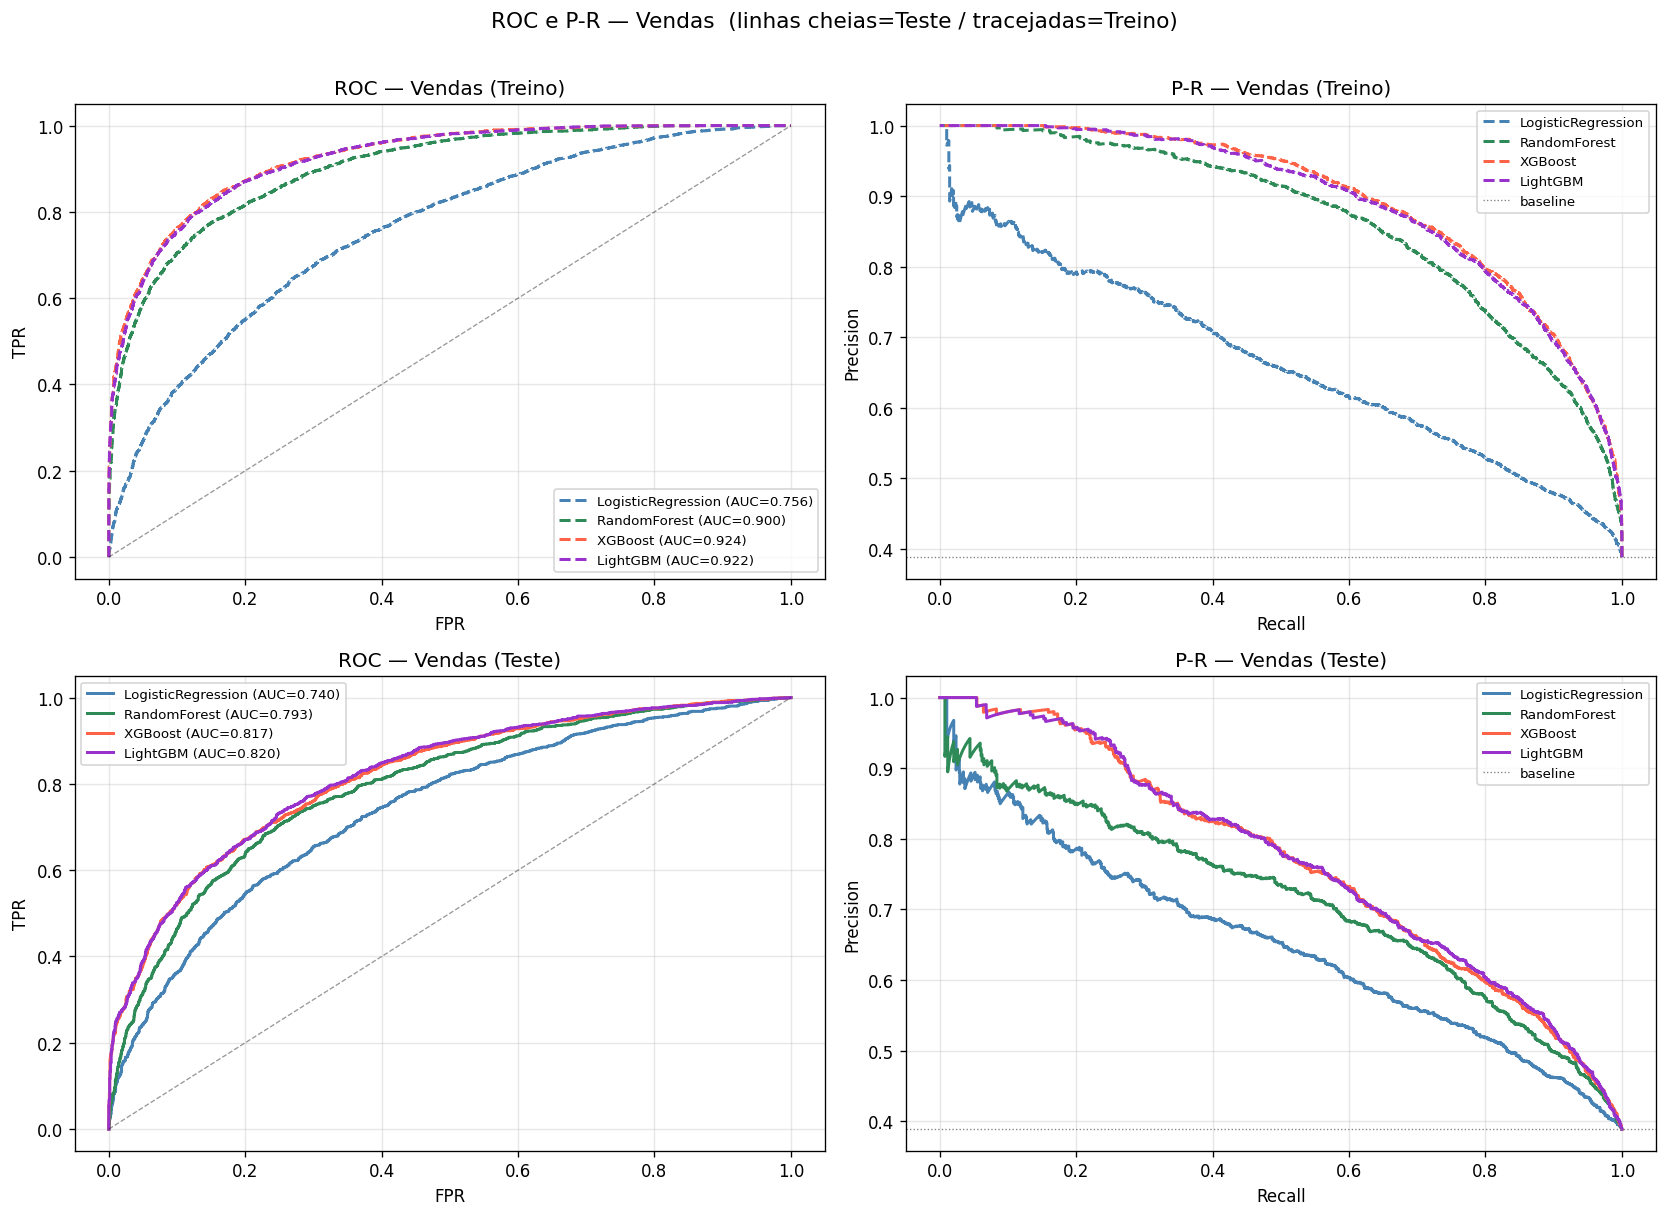


  Threshold=0.4000  |  Recall=0.7966  |  Precision=0.6096  (Fbeta=0.7324)
  (threshold selecionado no TESTE; será aplicado fixo na val)


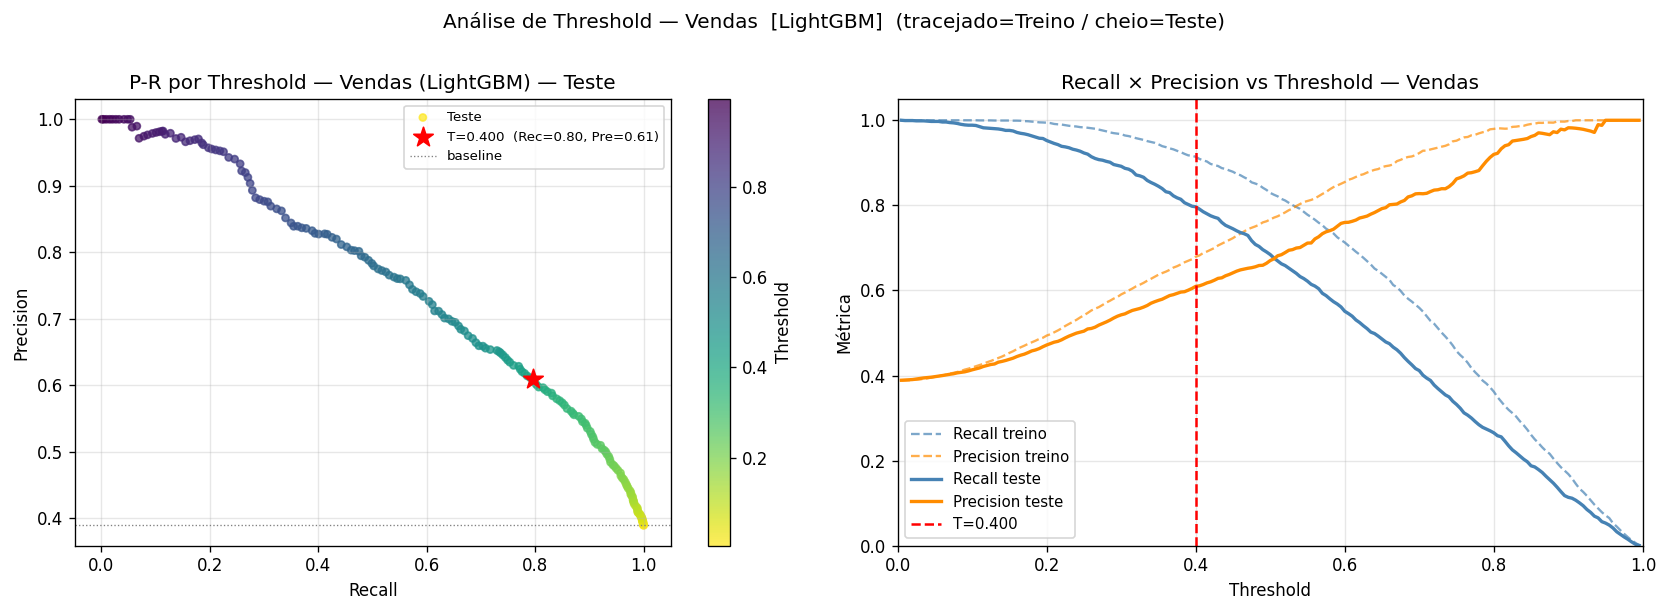

  M (pct 25 treino): 0.2208  |  T: 0.4000

  Teste (threshold definido aqui):
    AUC=0.8197  Recall=0.7966  Precision=0.6096  F1=0.6907
  Val temporal (out-of-time, threshold aplicado):
    AUC=0.7344  Recall=0.7663  Precision=0.2538  F1=0.3813


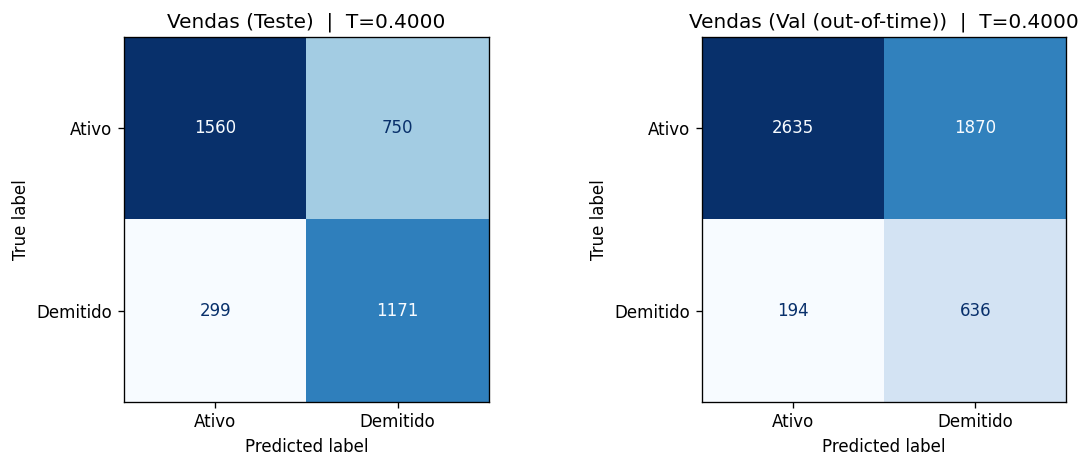

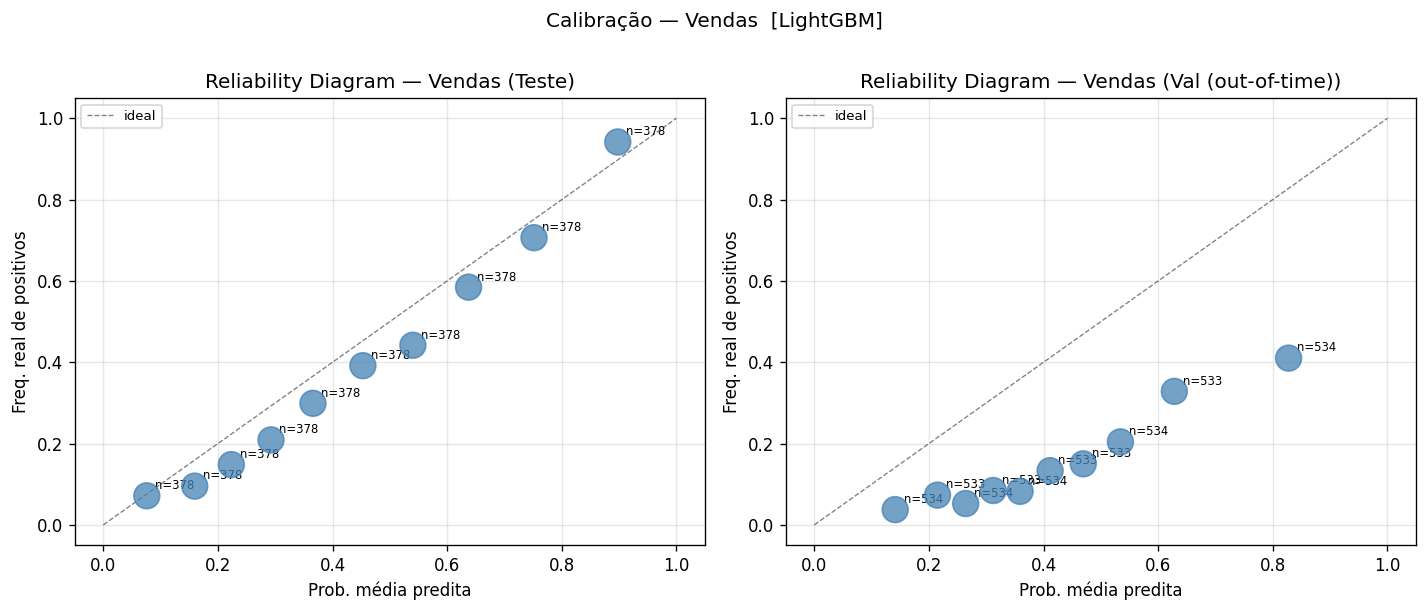


  Categorias (teste, T=0.4000): TP=1,171  FP=750  FN=299  TN=1,560

  Perfil médio top-10 features por categoria (teste):
cat                                  TP     FP     FN
vl_falta_horas_med_6m_bin         3.668  3.471  2.769
vl_dias_menos_6_horas_med_3m      0.410  0.170 -0.268
vl_horas_extras_horas_med_6m_bin  3.278  3.108  2.843
vl_positivo_banco_horas_med_3m    0.322  0.036 -0.097
vl_atraso_horas_med_6m            0.391  0.058 -0.096
vl_falta_horas_med_3m_y           0.308  0.188 -0.213
vl_horas_extras_horas_med_3m      0.309  0.051 -0.057
vl_atraso_horas_med_3m_x          0.286  0.085 -0.165
vl_tv_vol_cargo_4m                0.167  0.116 -0.077
vl_adc_not_dias_med_3m            0.187  0.155 -0.218

  ✓ best_model.joblib  +  model_metadata.json  →  models/Vendas/

GRUPO: Transporte
  Features: 46  |  RFECV AUC: 0.8657
  Treino : 12,795 × 46  |  turnover: 37.05%
  Teste  : 5,449 × 46  |  turnover: 36.45%
  Val    : 8,026 × 46  |  turnover: 12.75%  (out-of-time)

  Modelo       

  LogisticRegression        0.7623   0.6172    0.6762    0.5676


  RandomForest              0.8401   0.6935    0.7080    0.6796


  XGBoost                   0.8638   0.7221    0.7452    0.7004


  LightGBM                  0.8642   0.7231    0.7508    0.6974

  ✓ Melhor: LightGBM  (AUC teste = 0.8642)


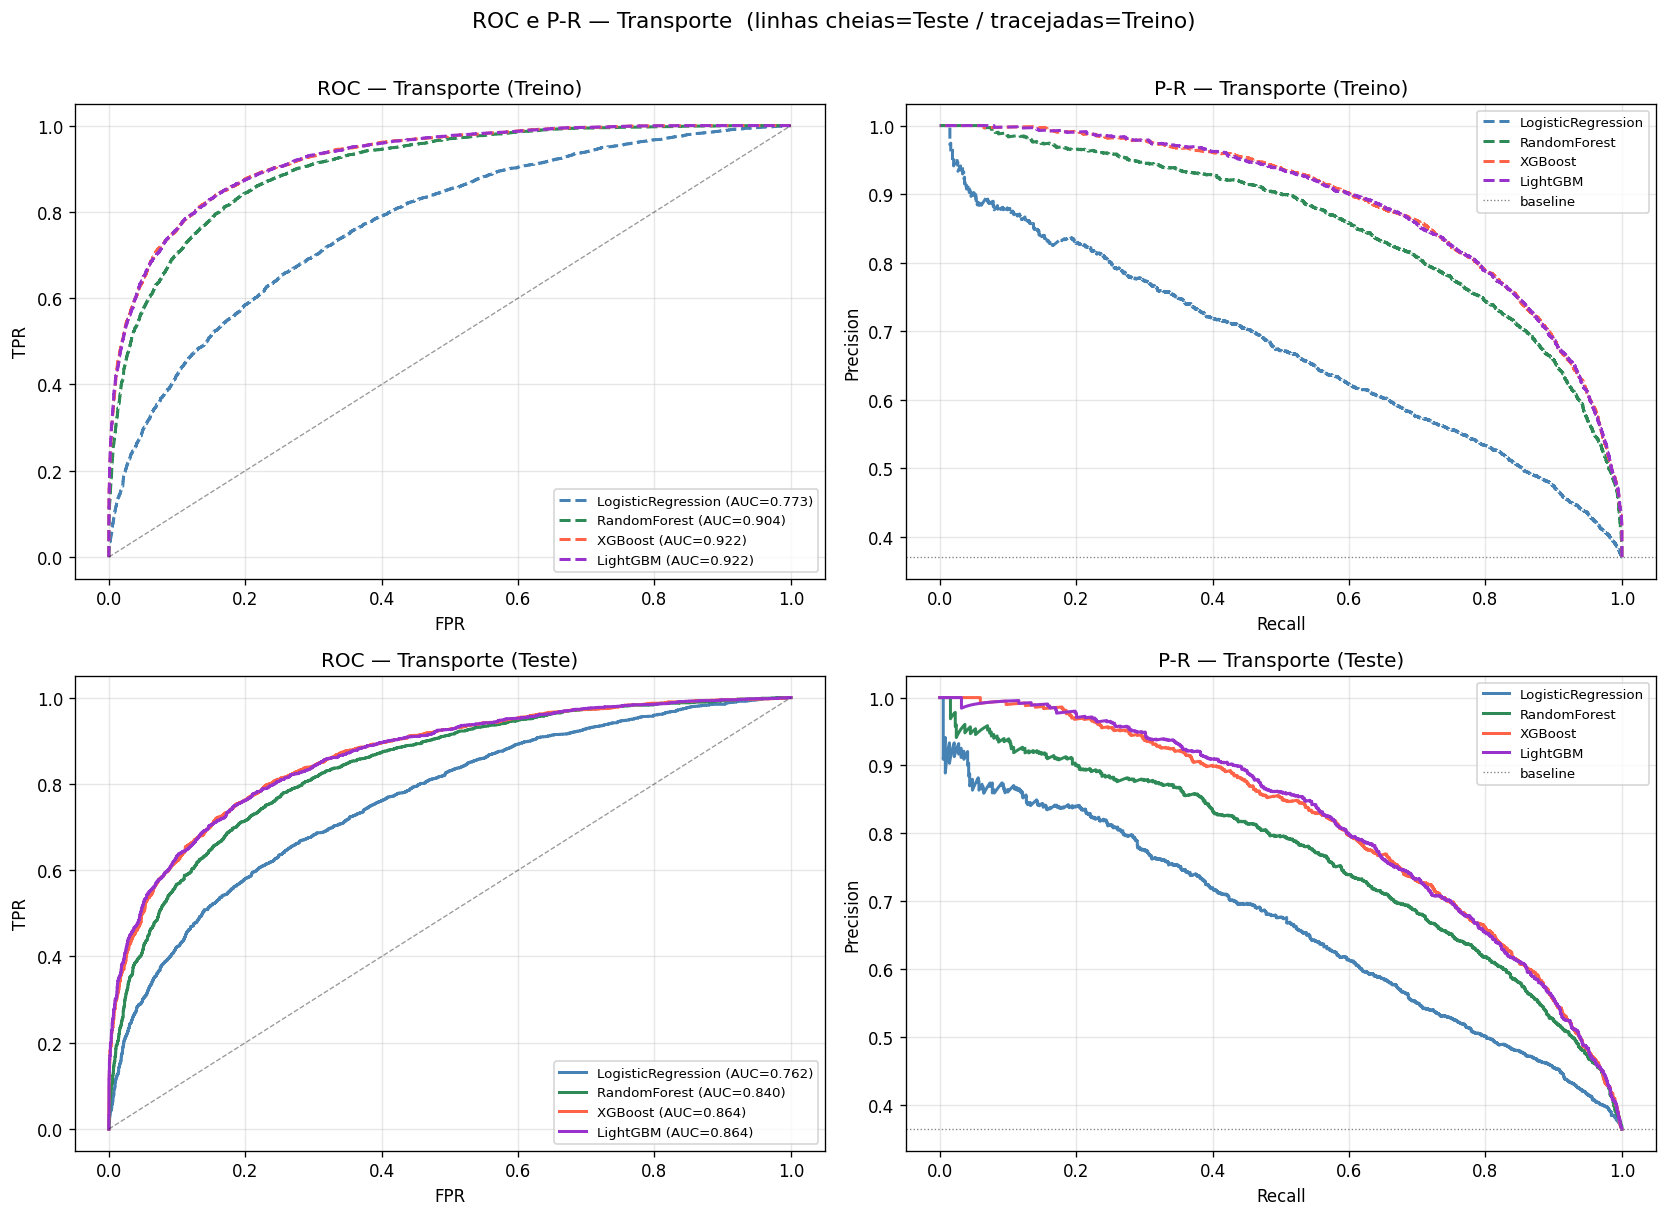


  Threshold=0.3600  |  Recall=0.8580  |  Precision=0.6064  (Fbeta=0.7671)
  (threshold selecionado no TESTE; será aplicado fixo na val)


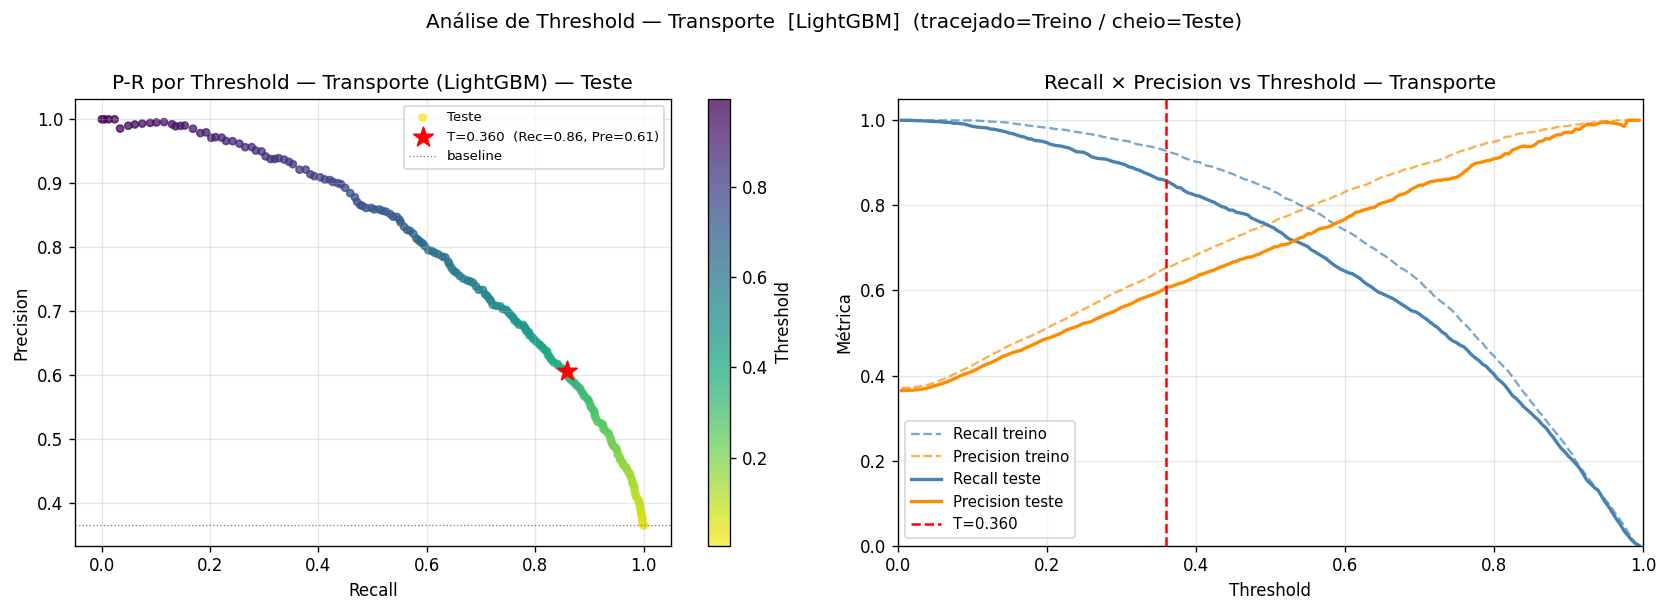

  M (pct 25 treino): 0.1731  |  T: 0.3600

  Teste (threshold definido aqui):
    AUC=0.8642  Recall=0.8580  Precision=0.6064  F1=0.7106
  Val temporal (out-of-time, threshold aplicado):
    AUC=0.8061  Recall=0.6061  Precision=0.3695  F1=0.4591


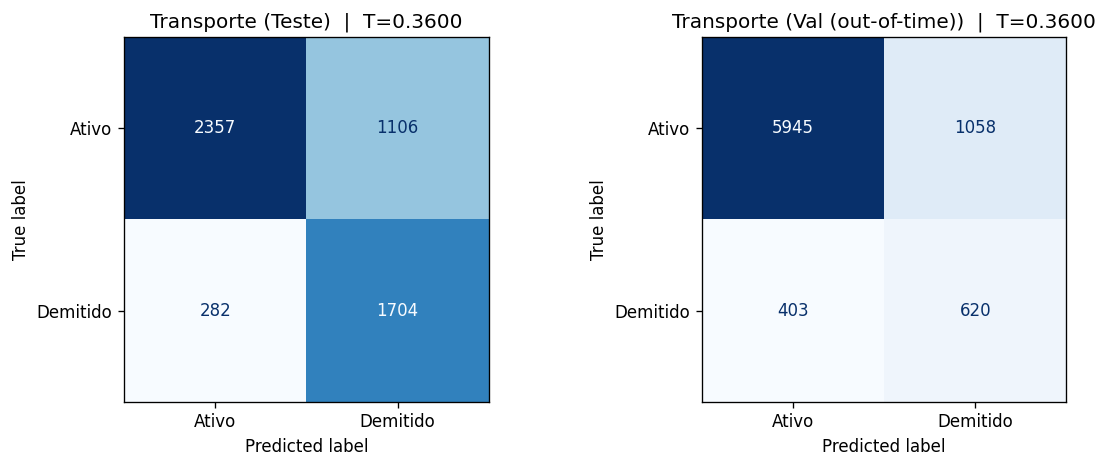

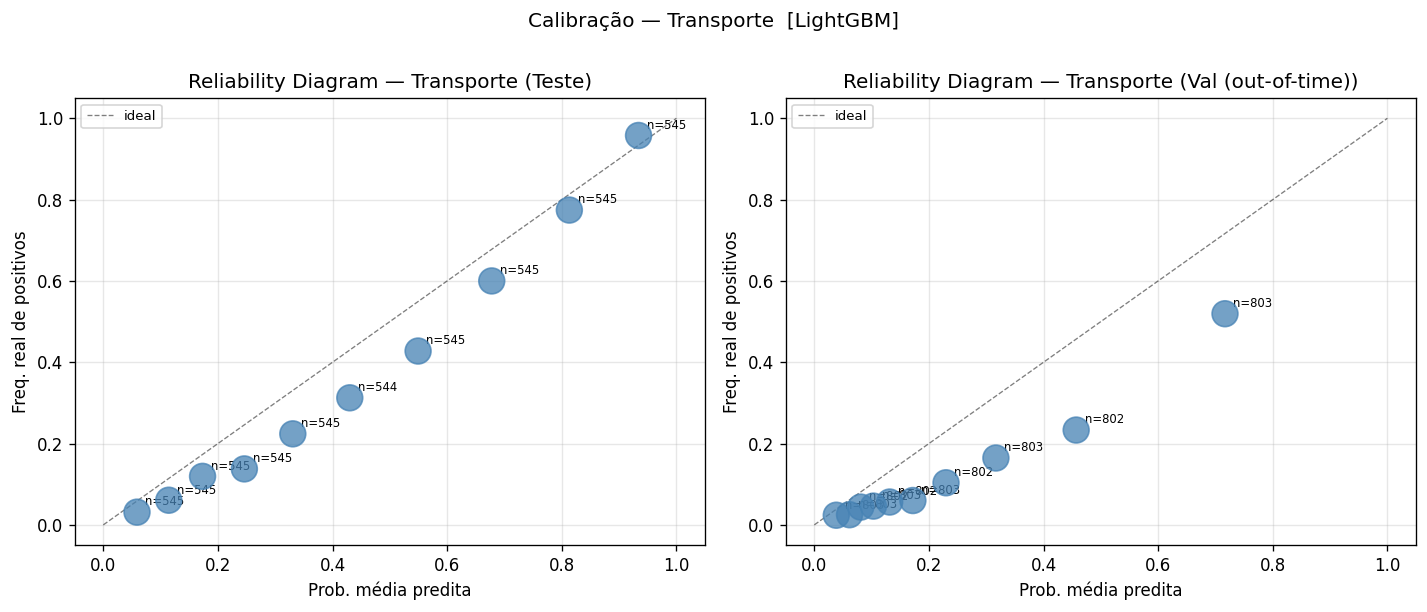


  Categorias (teste, T=0.3600): TP=1,704  FP=1,106  FN=282  TN=2,357

  Perfil médio top-10 features por categoria (teste):
cat                                 TP     FP     FN
vl_dias_menos_6_horas_med_3m     0.421  0.120 -0.173
vl_falta_horas_med_3m_y          0.444  0.081 -0.038
vl_falta_horas_med_6m_bin        3.725  3.494  2.993
vl_atraso_horas_med_3m_x         0.285 -0.027 -0.200
vl_atraso_horas_med_6m_bin       4.244  4.080  3.755
vl_atraso_horas_med_3m_y_bin     4.147  3.967  3.723
vl_idade                        -0.192 -0.105 -0.078
vl_banco_horas_pagamento_med_3m -0.241  0.028  0.122
vl_tempo_empresa                -0.161 -0.085 -0.145
qt_tempo_funcao                 -0.182 -0.123 -0.114

  ✓ best_model.joblib  +  model_metadata.json  →  models/Transporte/

GRUPO: Fábrica
  Features: 56  |  RFECV AUC: 0.8506
  Treino : 3,223 × 56  |  turnover: 38.38%
  Teste  : 1,356 × 56  |  turnover: 39.16%
  Val    : 1,831 × 56  |  turnover: 16.06%  (out-of-time)

  Modelo                

  LogisticRegression        0.6947   0.5676    0.5932    0.5440


  RandomForest              0.7220   0.5476    0.4821    0.6337


  XGBoost                   0.7463   0.5777    0.5217    0.6472
  LightGBM                  0.7391   0.5829    0.5461    0.6250

  ✓ Melhor: XGBoost  (AUC teste = 0.7463)


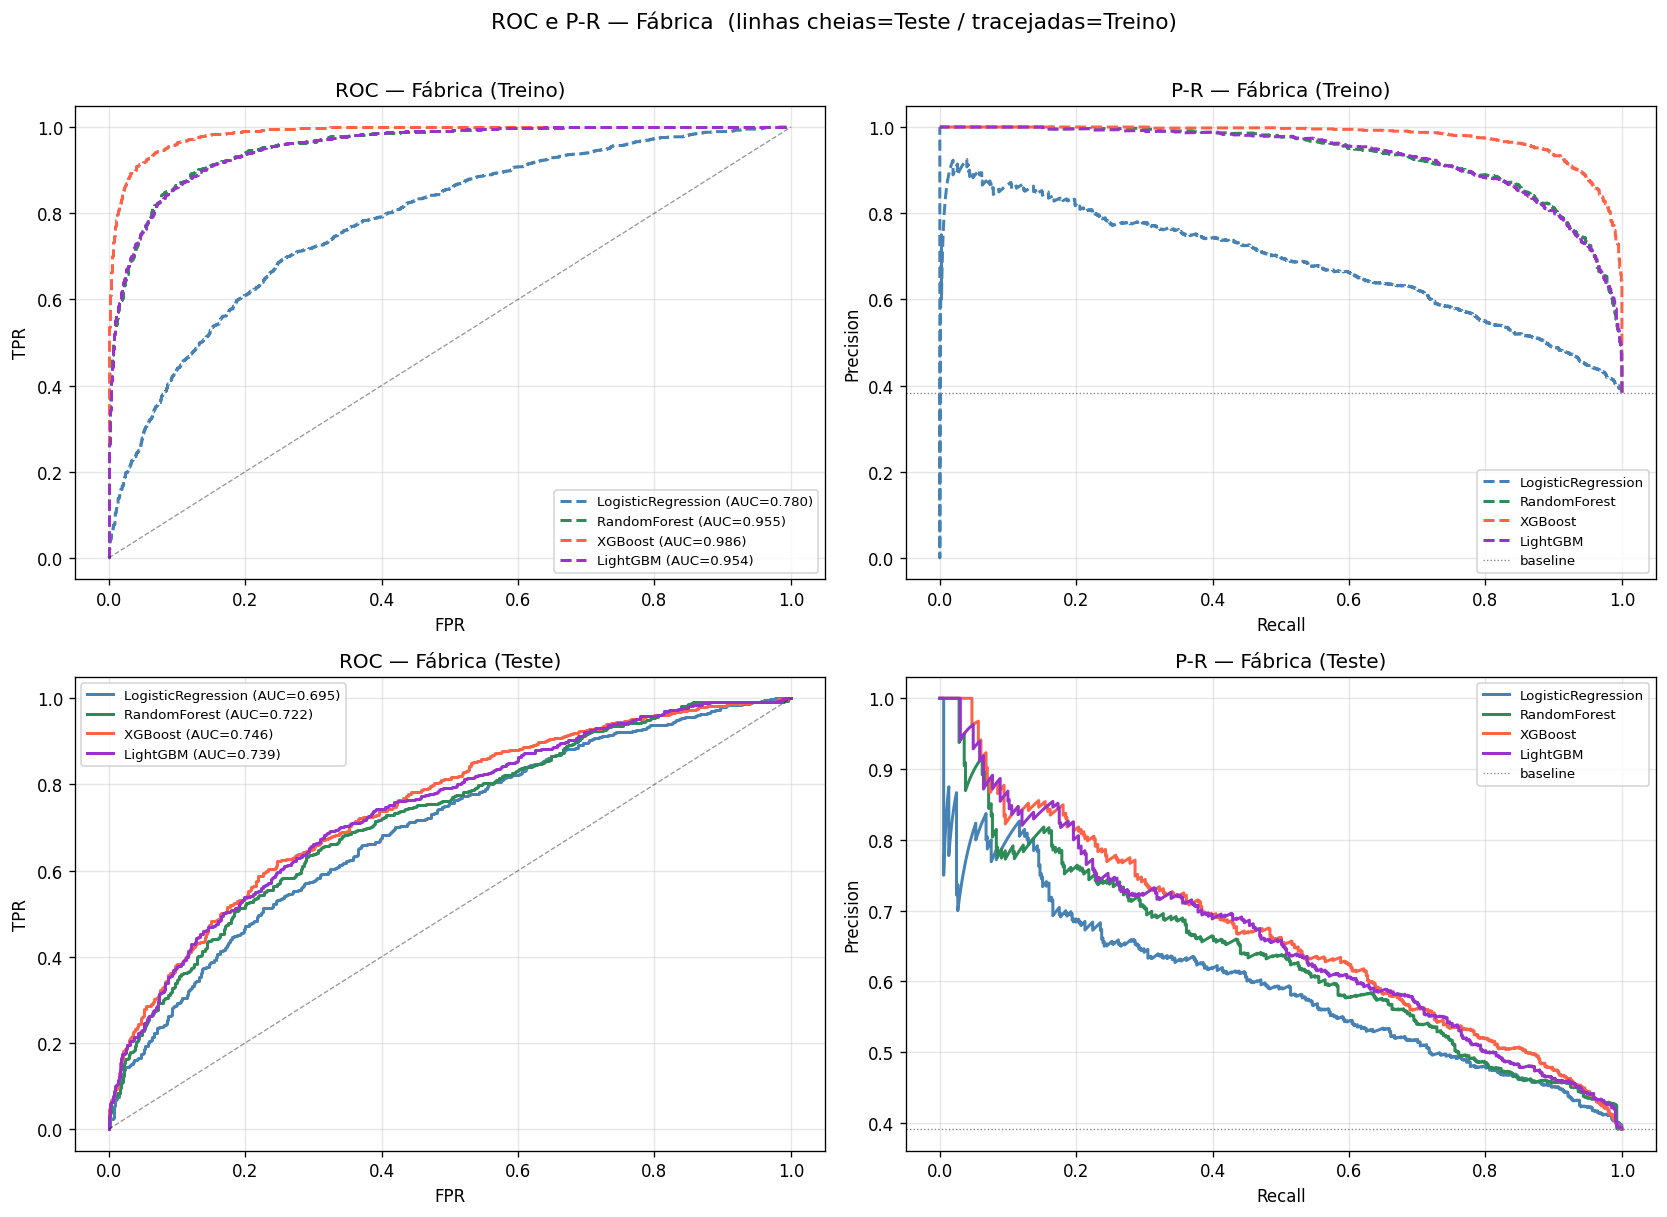


  Threshold=0.3550  |  Recall=0.7043  |  Precision=0.5624  (Fbeta=0.6570) [fallback: Pre≥0.55, max prec]
  (threshold selecionado no TESTE; será aplicado fixo na val)


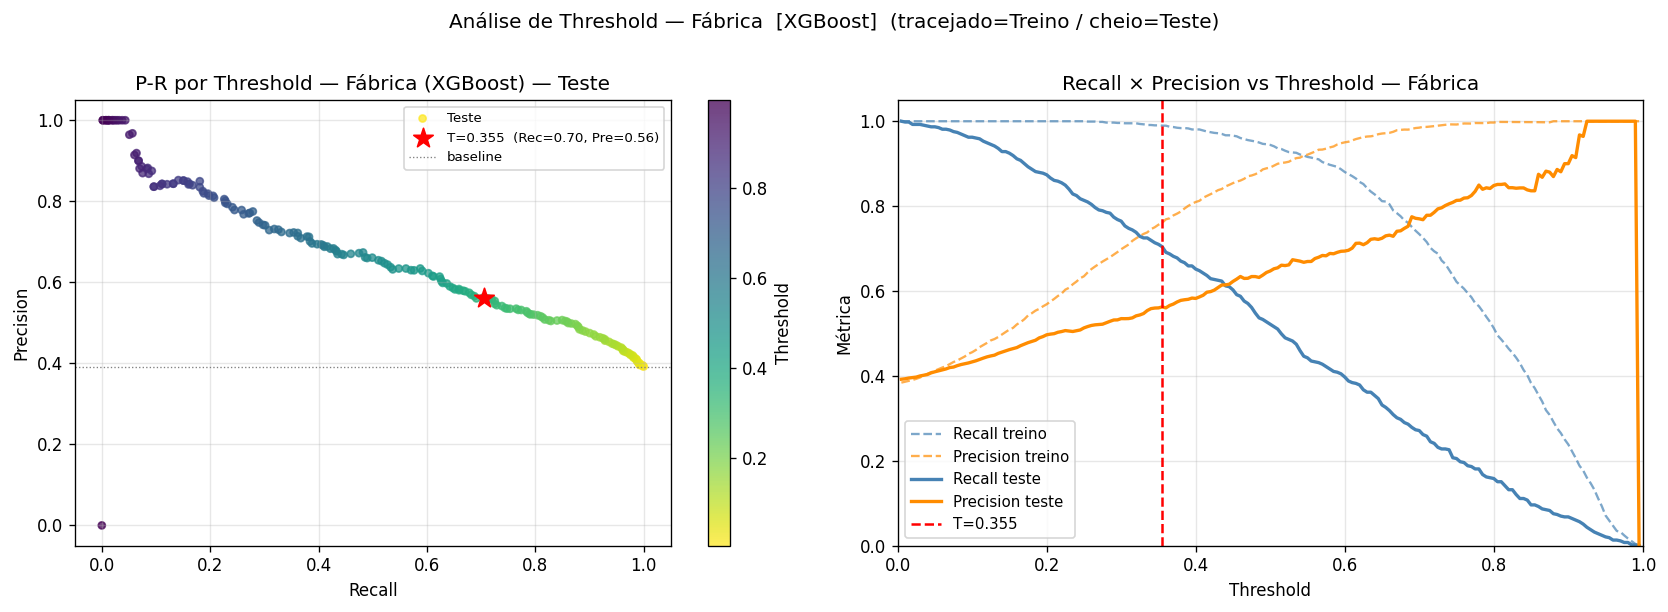

  M (pct 25 treino): 0.1532  |  T: 0.3550

  Teste (threshold definido aqui):
    AUC=0.7463  Recall=0.7043  Precision=0.5624  F1=0.6254
  Val temporal (out-of-time, threshold aplicado):
    AUC=0.6963  Recall=0.5952  Precision=0.2931  F1=0.3928


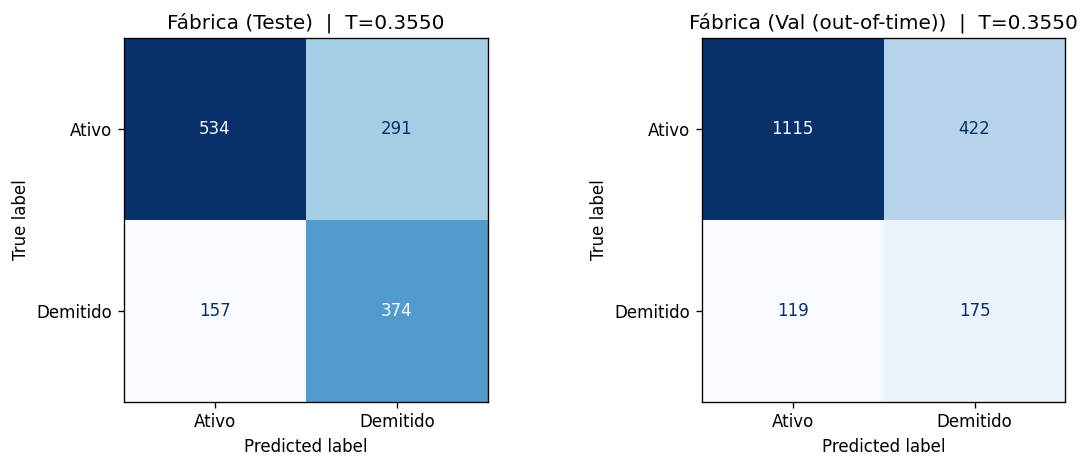

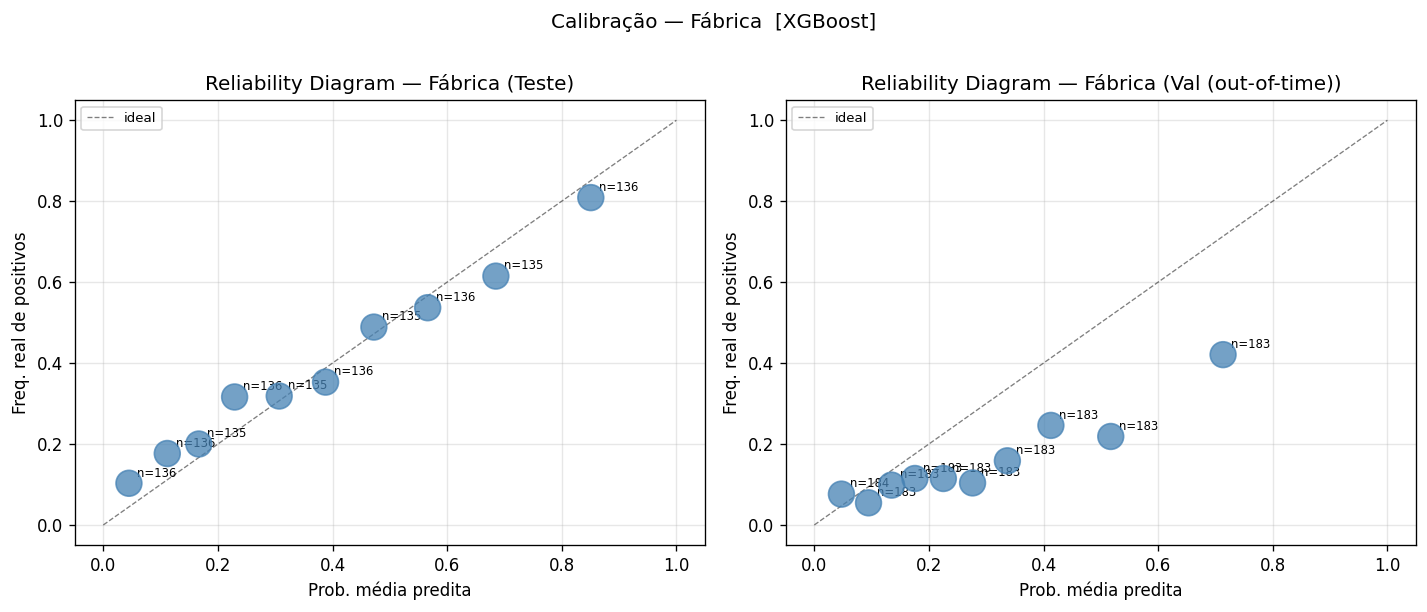


  Categorias (teste, T=0.3550): TP=374  FP=291  FN=157  TN=534

  Perfil médio top-10 features por categoria (teste):
cat                              TP     FP     FN
vl_dias_menos_6_horas_med_3m  0.272 -0.052 -0.053
vl_dias_domingo_med_3m_x     -0.378 -0.096  0.170
vl_falta_horas_med_3m_y       0.274 -0.049 -0.004
vl_horas_extras_horas_med_3m  0.270 -0.031 -0.108
vl_falta_horas_med_6m_bin     3.471  3.151  3.127
vl_tempo_promocao            -0.275  0.199 -0.155
vl_atraso_horas_med_3m_x      0.266 -0.002 -0.221
vl_atraso_horas_med_6m        0.293  0.082 -0.203
vl_falta_dias_med_6m          0.173 -0.017 -0.086
vl_tempo_empresa             -0.273 -0.156 -0.083

  ✓ best_model.joblib  +  model_metadata.json  →  models/Fábrica/

✓ Modelagem concluída para 3 grupos: ['Vendas', 'Transporte', 'Fábrica']


In [3]:

# ── Modelagem por grupo operacional ──────────────────────────
# Para cada grupo:
#   - treina LR/RF/XGBoost/LightGBM no split treino (70%)
#   - seleciona o melhor modelo por AUC no teste (30%)
#   - otimiza o threshold no teste (F-beta β²=2.5)
#   - aplica o threshold na validação temporal (out-of-time) — sem ajuste aqui
#   - salva modelo + metadados + gráficos

for GRUPO in GRUPOS:
    print(f"\n{'='*65}")
    print(f"GRUPO: {GRUPO}")
    print('='*65)

    # ── Diretórios do grupo ───────────────────────────────────
    grupo_splits  = DATA_SPLITS / GRUPO
    grupo_fs_dir  = FS_DIR      / GRUPO
    grupo_models  = MODELS_DIR  / GRUPO
    grupo_reports = REPORTS_DIR / GRUPO
    grupo_models.mkdir(parents=True, exist_ok=True)
    grupo_reports.mkdir(parents=True, exist_ok=True)

    # ── Carregar metadados ────────────────────────────────────
    scaler_info = json.loads((grupo_splits / "scaler_cols.json").read_text(encoding="utf-8"))
    fs_info     = json.loads((grupo_fs_dir  / "selected_features.json").read_text(encoding="utf-8"))
    COL_ID     = scaler_info["col_id"]
    COL_TARGET = scaler_info["col_target"]
    COL_DATA   = scaler_info["col_data"]
    FEATURES   = fs_info["selected_features"]
    print(f"  Features: {len(FEATURES)}  |  RFECV AUC: {fs_info['rfecv_best_auc']:.4f}")

    # ── Carregar splits ───────────────────────────────────────
    # train/test: mesmo período (Jan/2024–Mai/2025), IDs disjuntos
    # val      : período futuro (Jun–Ago/2025), out-of-time — apenas aplicação
    df_train = pd.read_parquet(grupo_splits / "train.parquet")
    df_test  = pd.read_parquet(grupo_splits / "test.parquet")
    df_val   = pd.read_parquet(grupo_splits / "val.parquet")

    X_train = df_train[FEATURES].copy()
    y_train = df_train[COL_TARGET].copy()
    X_test  = df_test[FEATURES].copy()
    y_test  = df_test[COL_TARGET].copy()
    X_val   = df_val[FEATURES].copy()
    y_val   = df_val[COL_TARGET].copy()

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    spw = neg / pos

    print(f"  Treino : {X_train.shape[0]:,} × {X_train.shape[1]}  |  turnover: {y_train.mean():.2%}")
    print(f"  Teste  : {X_test.shape[0]:,} × {X_test.shape[1]}  |  turnover: {y_test.mean():.2%}")
    print(f"  Val    : {X_val.shape[0]:,} × {X_val.shape[1]}  |  turnover: {y_val.mean():.2%}  (out-of-time)")

    # ── 3 · Treinamento ──────────────────────────────────────
    # Eval set = teste (early stopping de convergência; threshold sera otimizado no teste)
    models = {
        "LogisticRegression": LogisticRegression(
            class_weight="balanced", max_iter=1000,
            random_state=RNG_SEED, solver="lbfgs",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            max_depth=8, min_samples_leaf=5,
            random_state=RNG_SEED, n_jobs=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=spw, random_state=RNG_SEED,
            eval_metric="logloss", verbosity=0, n_jobs=-1,
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=spw, random_state=RNG_SEED,
            verbose=-1, n_jobs=-1,
        ),
    }

    results = {}
    trained = {}

    # Cabeçalho — métricas no TESTE (threshold=0.5, apenas para ranking inicial)
    print(f"\n  {'Modelo':<22} {'AUC-test':>9} {'F1-test':>8} {'Rec-test':>9} {'Pre-test':>9}")
    print("  " + "-"*60)

    for name, clf in models.items():
        if name == "XGBoost":
            clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        elif name == "LightGBM":
            clf.fit(X_train, y_train, eval_set=[(X_test, y_test)],
                    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        else:
            clf.fit(X_train, y_train)

        proba_tr   = clf.predict_proba(X_train)[:, 1]
        proba_test = clf.predict_proba(X_test)[:, 1]
        pred_test  = (proba_test >= 0.5).astype(int)

        auc_test = roc_auc_score(y_test, proba_test)
        f1_test  = f1_score(y_test, pred_test,      zero_division=0)
        rec_test = recall_score(y_test, pred_test,   zero_division=0)
        pre_test = precision_score(y_test, pred_test, zero_division=0)

        results[name] = {
            "auc_test"  : auc_test,
            "proba_train": proba_tr,
            "proba_test" : proba_test,
        }
        trained[name] = clf
        print(f"  {name:<22} {auc_test:>9.4f} {f1_test:>8.4f} {rec_test:>9.4f} {pre_test:>9.4f}")

    best_name  = max(results, key=lambda k: results[k]["auc_test"])
    best_model = trained[best_name]
    best_proba_train = results[best_name]["proba_train"]
    best_proba_test  = results[best_name]["proba_test"]
    print(f"\n  ✓ Melhor: {best_name}  (AUC teste = {results[best_name]['auc_test']:.4f})")

    # ── 4 · Curvas ROC e P-R — treino vs teste, todos os modelos ─
    # 4 plots em grade 2×2:
    #   linha superior  = treino   (ROC | P-R)
    #   linha inferior  = teste    (ROC | P-R)
    colors = {"LogisticRegression": "steelblue", "RandomForest": "seagreen",
              "XGBoost": "tomato", "LightGBM": "darkorchid"}

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for row_idx, (split_label, y_split, proba_key) in enumerate([
        ("Treino", y_train, "proba_train"),
        ("Teste",  y_test,  "proba_test"),
    ]):
        ax_roc, ax_pr = axes[row_idx]
        for name, res in results.items():
            proba_s = res[proba_key]
            fpr, tpr, _ = roc_curve(y_split, proba_s)
            p_c, r_c, _ = precision_recall_curve(y_split, proba_s)
            auc_s = roc_auc_score(y_split, proba_s)
            ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc_s:.3f})",
                        color=colors[name], linewidth=1.8,
                        linestyle="--" if split_label == "Treino" else "-")
            ax_pr.plot(r_c, p_c, label=name, color=colors[name], linewidth=1.8,
                       linestyle="--" if split_label == "Treino" else "-")
        ax_roc.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4)
        ax_roc.set(xlabel="FPR", ylabel="TPR",
                   title=f"ROC — {GRUPO} ({split_label})")
        ax_roc.legend(fontsize=8); ax_roc.grid(alpha=0.3)
        ax_pr.axhline(y_split.mean(), color="gray", linestyle=":", linewidth=0.8,
                      label="baseline")
        ax_pr.set(xlabel="Recall", ylabel="Precision",
                  title=f"P-R — {GRUPO} ({split_label})")
        ax_pr.legend(fontsize=8); ax_pr.grid(alpha=0.3)

    plt.suptitle(f"ROC e P-R — {GRUPO}  (linhas cheias=Teste / tracejadas=Treino)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(grupo_reports / "roc_pr_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── 5 · Threshold ótimo — definido no TESTE ───────────────
    # Varredura em grid de 0.005; maximizar F-beta (β²=2.5, recall 2.5× precision).
    # Constraint invariante: recall ≥ precision.
    # Filtros em cascata: Rec≥0.70 & Pre≥0.60 → Pre≥0.50 → Rec≥0.70 → max recall.
    BETA2 = 2.5

    grid_th = np.arange(0.005, 1.0, 0.005)
    rows_th = []
    for th in grid_th:
        pred_g = (best_proba_test >= th).astype(int)
        r = recall_score(y_test,    pred_g, zero_division=0)
        p = precision_score(y_test, pred_g, zero_division=0)
        denom = BETA2 * p + r
        fb = (1 + BETA2) * p * r / denom if denom > 0 else 0.0
        rows_th.append({"threshold": th, "recall": r, "precision": p, "fbeta": fb})
    df_th = pd.DataFrame(rows_th)

    df_th_ok = df_th[df_th["recall"] >= df_th["precision"]].copy()
    if df_th_ok.empty:
        df_th_ok = df_th.nlargest(1, "recall")

    mask_strict = (df_th_ok["recall"] >= 0.70) & (df_th_ok["precision"] >= 0.60)
    candidates  = df_th_ok[mask_strict].copy()
    fallback_label = ""
    _sort_by = "fbeta"       # Tier 1: max F-beta (prioriza recall)

    if candidates.empty:
        # Fallback 1: relaxa precisão para 0.55; seleciona max precisão
        # Evita escolher pontos de recall muito alto / precisão muito baixa
        mask_f1 = (df_th_ok["recall"] >= 0.70) & (df_th_ok["precision"] >= 0.55)
        candidates = df_th_ok[mask_f1].copy()
        fallback_label = " [fallback: Pre≥0.55, max prec]"
        _sort_by = "precision"

    if candidates.empty:
        mask_f2 = (df_th_ok["recall"] >= 0.70) & (df_th_ok["precision"] >= 0.50)
        candidates = df_th_ok[mask_f2].copy()
        fallback_label = " [fallback: Pre≥0.50, max prec]"
        _sort_by = "precision"

    if candidates.empty:
        mask_f3 = df_th_ok["recall"] >= 0.70
        candidates = df_th_ok[mask_f3].copy()
        fallback_label = " [fallback: Rec≥0.70 apenas, max prec]"
        _sort_by = "precision"

    if candidates.empty:
        best_th_row = df_th_ok.sort_values("recall", ascending=False).iloc[0]
        fallback_label = f" [quase: max Rec={best_th_row['recall']:.3f}]"
    else:
        best_th_row = candidates.sort_values(_sort_by, ascending=False).iloc[0]

    THRESHOLD = float(best_th_row["threshold"])
    T         = THRESHOLD
    print(f"\n  Threshold={T:.4f}  |  "
          f"Recall={best_th_row['recall']:.4f}  |  Precision={best_th_row['precision']:.4f}  "
          f"(Fbeta={best_th_row['fbeta']:.4f}){fallback_label}")
    print(f"  (threshold selecionado no TESTE; será aplicado fixo na val)")

    # ── 5b · Análise do threshold — treino e teste ────────────
    # Esquerda: scatter P×R no teste colorido por threshold (melhor modelo).
    #   A estrela vermelha marca o threshold selecionado.
    # Direita: Recall e Precision vs threshold no treino e no teste.
    #   Duas linhas por métrica (treino tracejado, teste cheio).

    # Recalcular sweep para o treino (para o plot comparativo)
    rows_tr = []
    for th in grid_th:
        pred_g = (best_proba_train >= th).astype(int)
        r = recall_score(y_train,    pred_g, zero_division=0)
        p = precision_score(y_train, pred_g, zero_division=0)
        rows_tr.append({"threshold": th, "recall": r, "precision": p})
    df_th_train = pd.DataFrame(rows_tr)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Esquerda — scatter P×R no teste
    sc = axes[0].scatter(df_th["recall"], df_th["precision"],
                         c=df_th["threshold"], cmap="viridis_r", s=18, alpha=0.75,
                         label="Teste")
    plt.colorbar(sc, ax=axes[0], label="Threshold")
    axes[0].scatter(best_th_row["recall"], best_th_row["precision"],
                    color="red", s=150, zorder=6, marker="*",
                    label=f"T={T:.3f}  (Rec={best_th_row['recall']:.2f}, "
                          f"Pre={best_th_row['precision']:.2f})")
    axes[0].axhline(y_test.mean(), color="gray", ls=":", lw=0.8, label="baseline")
    axes[0].set(xlabel="Recall", ylabel="Precision",
                title=f"P-R por Threshold — {GRUPO} ({best_name}) — Teste")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    # Direita — Recall e Precision vs threshold (treino + teste)
    axes[1].plot(df_th_train["threshold"], df_th_train["recall"],
                 color="steelblue",  lw=1.4, ls="--", alpha=0.7, label="Recall treino")
    axes[1].plot(df_th_train["threshold"], df_th_train["precision"],
                 color="darkorange", lw=1.4, ls="--", alpha=0.7, label="Precision treino")
    axes[1].plot(df_th["threshold"], df_th["recall"],
                 color="steelblue",  lw=2.0, label="Recall teste")
    axes[1].plot(df_th["threshold"], df_th["precision"],
                 color="darkorange", lw=2.0, label="Precision teste")
    axes[1].axvline(x=T, color="red", ls="--", lw=1.5, label=f"T={T:.3f}")
    axes[1].set(xlabel="Threshold", ylabel="Métrica", xlim=(0, 1), ylim=(0, 1.05),
                title=f"Recall × Precision vs Threshold — {GRUPO}")
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    plt.suptitle(f"Análise de Threshold — {GRUPO}  [{best_name}]  "
                 f"(tracejado=Treino / cheio=Teste)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(grupo_reports / "pr_threshold_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── 6 · Score de risco / M (SPEC §14) ────────────────────
    proba_train_best = best_proba_train
    M = float(np.percentile(proba_train_best, MEDIO_RISCO_PERCENTIL))
    print(f"  M (pct {MEDIO_RISCO_PERCENTIL} treino): {M:.4f}  |  T: {T:.4f}")

    # ── 7 · Avaliação final — teste e val temporal ───────────
    def _avaliar(y_true, proba, threshold):
        pred = (proba >= threshold).astype(int)
        return {
            "auc"      : roc_auc_score(y_true, proba),
            "f1"       : f1_score(y_true, pred, zero_division=0),
            "recall"   : recall_score(y_true, pred, zero_division=0),
            "precision": precision_score(y_true, pred, zero_division=0),
        }

    best_proba_val   = best_model.predict_proba(X_val)[:, 1]
    metrics_test = _avaliar(y_test, best_proba_test, T)
    metrics_val  = _avaliar(y_val,  best_proba_val,  T)

    print(f"\n  Teste (threshold definido aqui):")
    print(f"    AUC={metrics_test['auc']:.4f}  Recall={metrics_test['recall']:.4f}"
          f"  Precision={metrics_test['precision']:.4f}  F1={metrics_test['f1']:.4f}")
    print(f"  Val temporal (out-of-time, threshold aplicado):")
    print(f"    AUC={metrics_val['auc']:.4f}  Recall={metrics_val['recall']:.4f}"
          f"  Precision={metrics_val['precision']:.4f}  F1={metrics_val['f1']:.4f}")

    # Matrizes de confusão — teste e val
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, y_true, proba, titulo in [
        (axes[0], y_test, best_proba_test, "Teste"),
        (axes[1], y_val,  best_proba_val,  "Val (out-of-time)"),
    ]:
        pred = (proba >= T).astype(int)
        cm   = confusion_matrix(y_true, pred)
        ConfusionMatrixDisplay(cm, display_labels=["Ativo", "Demitido"]).plot(
            ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{GRUPO} ({titulo})  |  T={T:.4f}")
    plt.tight_layout()
    plt.savefig(grupo_reports / "confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── 7b · Reliability diagram — teste e val ───────────────
    _N_BINS = 10
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, proba_c, y_c, split_lbl in [
        (axes[0], best_proba_test, y_test, "Teste"),
        (axes[1], best_proba_val,  y_val,  "Val (out-of-time)"),
    ]:
        _proba_s = pd.Series(proba_c, name="proba")
        _y_s     = pd.Series(y_c.values,   name="target")
        _bins    = pd.qcut(_proba_s, q=_N_BINS, duplicates="drop")
        _cal_df  = pd.DataFrame({"proba": _proba_s, "target": _y_s, "bin": _bins})
        _cal_grp = _cal_df.groupby("bin", observed=True).agg(
            mean_pred=("proba",  "mean"),
            freq_real=("target", "mean"),
            n=("target",         "count"),
        ).reset_index()
        ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5, label="ideal")
        _sizes = (_cal_grp["n"] / _cal_grp["n"].max() * 200 + 40).values
        ax.scatter(_cal_grp["mean_pred"], _cal_grp["freq_real"],
                   s=_sizes, color="steelblue", alpha=0.75, zorder=5)
        for _, _row_c in _cal_grp.iterrows():
            ax.annotate(f"n={int(_row_c['n'])}",
                        (_row_c["mean_pred"], _row_c["freq_real"]),
                        textcoords="offset points", xytext=(5, 4), fontsize=7)
        ax.set(xlabel="Prob. média predita", ylabel="Freq. real de positivos",
               title=f"Reliability Diagram — {GRUPO} ({split_lbl})")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle(f"Calibração — {GRUPO}  [{best_name}]", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(grupo_reports / "reliability_diagram.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── 7c · Análise de erros — perfil TP/FP/FN no teste ─────
    _pred_T  = (best_proba_test >= T).astype(int)
    _df_err  = df_test[FEATURES + [COL_TARGET]].copy()
    _df_err["pred"] = _pred_T
    _df_err["cat"]  = "TN"
    _df_err.loc[(_df_err[COL_TARGET]==1) & (_df_err["pred"]==1), "cat"] = "TP"
    _df_err.loc[(_df_err[COL_TARGET]==1) & (_df_err["pred"]==0), "cat"] = "FN"
    _df_err.loc[(_df_err[COL_TARGET]==0) & (_df_err["pred"]==1), "cat"] = "FP"

    _cnt = _df_err["cat"].value_counts()
    print(f"\n  Categorias (teste, T={T:.4f}): "
          f"TP={_cnt.get('TP',0):,}  FP={_cnt.get('FP',0):,}  "
          f"FN={_cnt.get('FN',0):,}  TN={_cnt.get('TN',0):,}")

    _top_feats = (
        df_test[FEATURES + [COL_TARGET]]
        .corr(numeric_only=True)[COL_TARGET]
        .abs().drop(COL_TARGET, errors="ignore")
        .nlargest(10).index.tolist()
    )
    _cats_interesse = ["TP", "FP", "FN"]
    _mask_cats = _df_err["cat"].isin(_cats_interesse)
    if _mask_cats.sum() > 0:
        _perfil = (
            _df_err.loc[_mask_cats]
            .groupby("cat")[_top_feats]
            .mean().T.round(3)
        )
        _cols_ord = [c for c in _cats_interesse if c in _perfil.columns]
        print(f"\n  Perfil médio top-10 features por categoria (teste):")
        print(_perfil[_cols_ord].to_string())

    # ── 8 · Salvar modelo + metadados ────────────────────────
    model_path = grupo_models / "best_model.joblib"
    meta_path  = grupo_models / "model_metadata.json"
    joblib.dump(best_model, model_path)

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump({
            "grupo"                : GRUPO,
            "modelo"               : best_name,
            "features"             : FEATURES,
            "n_features"           : len(FEATURES),
            "col_target"           : COL_TARGET,
            "col_id"               : COL_ID,
            "col_data"             : COL_DATA,
            "threshold"            : T,
            "threshold_origem"     : "teste (30% IDs, mesmo período treino)",
            "M_medio_risco"        : M,
            "medio_risco_percentil": MEDIO_RISCO_PERCENTIL,
            # métricas no teste (onde T foi definido)
            "auc_test"       : metrics_test["auc"],
            "recall_test"    : metrics_test["recall"],
            "precision_test" : metrics_test["precision"],
            "f1_test"        : metrics_test["f1"],
            # métricas na val temporal (out-of-time, T aplicado sem ajuste)
            "auc_val"        : metrics_val["auc"],
            "recall_val"     : metrics_val["recall"],
            "precision_val"  : metrics_val["precision"],
            "f1_val"         : metrics_val["f1"],
            "criado_em"      : datetime.now().isoformat(),
        }, f, indent=2, ensure_ascii=False)

    print(f"\n  ✓ best_model.joblib  +  model_metadata.json  →  models/{GRUPO}/")

print(f"\n{'='*65}")
print(f"✓ Modelagem concluída para {len(GRUPOS)} grupos: {GRUPOS}")
print(f"{'='*65}")


## 3 · Treinamento dos Modelos (SPEC §12)

Quatro modelos treinados com tratamento de desbalanceamento via `class_weight` / `scale_pos_weight`.
Comparação no **val** por ROC-AUC, F1 e Recall.

In [4]:
# Treinamento dos modelos consolidado no loop por grupo acima.


## 4 · Curvas ROC e PR — Todos os Modelos

In [5]:
# Curvas ROC/PR consolidadas no loop por grupo acima.


## 5 · Otimização do Threshold — Melhor Modelo (SPEC §13)

Filtros obrigatórios:
- `threshold > 0.15`
- `Recall > 0.60`
- `Precision > 0.50`
- `Recall < 0.90`

Prioridade: maximizar **Recall**, desempate pelo **F-beta (β=2)**.

In [6]:
# Threshold ótimo consolidado no loop por grupo acima.


In [7]:
# Plot threshold consolidado no loop por grupo acima.


## 6 · Score de Risco por Colaborador (SPEC §14)

Reescala `[0, 1]` em três zonas:
- `prob < M` → Baixo risco `[0.00, 0.35)`
- `M ≤ prob < T` → Médio risco `[0.35, 0.50)`
- `prob ≥ T` → Alto risco `[0.50, 1.00]`

**M** = percentil 25 das probabilidades preditas no treino.

In [8]:
# Score de risco / M consolidado no loop por grupo acima.


## 7 · Avaliação Final com Threshold Ótimo — Val e Teste

In [9]:
# Avaliação final consolidada no loop por grupo acima.


## 8 · Salvar Modelo e Metadados

In [10]:
# Salvar modelo consolidado no loop por grupo acima.


In [11]:
# Resumo final consolidado no loop por grupo acima.


In [12]:

# ── Diagnóstico Fábrica: tabela threshold × Recall × Precision ─────────────
# df_th     = sweep completo no TESTE (sem filtro recall >= precision)
# df_th_ok  = apenas onde recall >= precision  ← filtro que exclui candidatos

print("=== Fábrica — sweep no TESTE ===")
print()
print("  Pontos onde Rec≥0.70 E Pre≥0.60 (sem filtro rec≥pre):")
_cond = (df_th["recall"] >= 0.70) & (df_th["precision"] >= 0.60)
_sub  = df_th[_cond].copy()
if _sub.empty:
    print("  → NENHUM ponto encontrado (mesmo sem filtro rec≥pre)")
else:
    print(_sub[["threshold","recall","precision","fbeta"]]
          .sort_values("threshold").to_string(index=False))

print()
print("  Pontos onde Rec≥0.70 E Pre≥0.60 E rec≥pre (filtro ativo):")
_cond2 = _cond & (df_th["recall"] >= df_th["precision"])
_sub2 = df_th[_cond2].copy()
if _sub2.empty:
    print("  → NENHUM (filtro rec≥pre remove todos ← CAUSA DO FALLBACK)")
else:
    print(_sub2[["threshold","recall","precision","fbeta"]]
          .sort_values("threshold").to_string(index=False))

print()
print("  Tabela de 0.20 a 0.65 (passo 0.005):")
print(f"  {'Threshold':>10}  {'Recall':>8}  {'Precision':>10}  {'Fbeta':>7}  {'Rec≥Pre':>8}  {'':>12}")
print("  " + "-"*65)
for _, row in df_th[(df_th["threshold"] >= 0.20) & (df_th["threshold"] <= 0.65)].iterrows():
    flag = ""
    if abs(row["threshold"] - T) < 0.003:
        flag = "<-- ESCOLHIDO"
    elif row["recall"] >= 0.70 and row["precision"] >= 0.60:
        flag = "<<< Rec≥0.70 Pre≥0.60"
    rec_ge_pre = "✓" if row["recall"] >= row["precision"] else "✗"
    print(f"  {row['threshold']:>10.3f}  {row['recall']:>8.4f}  {row['precision']:>10.4f}  "
          f"{row['fbeta']:>7.4f}  {rec_ge_pre:>8}  {flag}")


=== Fábrica — sweep no TESTE ===

  Pontos onde Rec≥0.70 E Pre≥0.60 (sem filtro rec≥pre):
  → NENHUM ponto encontrado (mesmo sem filtro rec≥pre)

  Pontos onde Rec≥0.70 E Pre≥0.60 E rec≥pre (filtro ativo):
  → NENHUM (filtro rec≥pre remove todos ← CAUSA DO FALLBACK)

  Tabela de 0.20 a 0.65 (passo 0.005):
   Threshold    Recall   Precision    Fbeta   Rec≥Pre              
  -----------------------------------------------------------------
       0.200    0.8738      0.4968   0.7181         ✓  
       0.205    0.8663      0.4984   0.7154         ✓  
       0.210    0.8606      0.4995   0.7133         ✓  
       0.215    0.8588      0.5028   0.7143         ✓  
       0.220    0.8550      0.5044   0.7134         ✓  
       0.225    0.8493      0.5067   0.7118         ✓  
       0.230    0.8399      0.5057   0.7065         ✓  
       0.235    0.8286      0.5046   0.7002         ✓  
       0.240    0.8249      0.5064   0.6992         ✓  
       0.245    0.8173      0.5082   0.6963         ✓